# Aula de Processamento de Sinais

## 🟢 Roteiro: Da Captura à Estabilidade do Sistema 

### Passo 1. O Problema (Caos Analógico)
O que é feito: Capturamos um sinal de voz (5 Hz) que está "sujo" com um ruído de 90 Hz.
Por que fazer: No mundo real, os sensores raramente entregam um sinal limpo; precisamos identificar o que é informação útil e o que é lixo.
Resultado: Um gráfico caótico onde a voz está escondida sob ondas rápidas de interferência.

### Passo 2: A Primeira Defesa (Filtro Analógico)O que é feito: Passamos o sinal por um circuito físico (Resistor + Capacitor) antes do ADC.
Por que fazer: Para obedecer ao Teorema de Nyquist. Se o ruído de 90 Hz entrar no conversor que só lê a 40 Hz, ele vira um "fantasma" (Aliasing) que o software nunca conseguirá apagar.Resultado: O sinal chega ao microcontrolador já "atenuado", mas ainda com algumas imperfeições que o software (DSP) precisa lapidar.

### Passo 3: O Refinamento Digital (Pólo 0.9 - Estabilidade)
O que é feito: Implementamos o filtro IIR no Python com um coeficiente $a = 0.9$ (nosso Pólo).
Por que fazer: Queremos que o sistema tenha "memória". O valor 0.9 significa que o filtro confia 90% no que já sabe e apenas 10% na leitura nova.
Resultado: Um sinal extremamente liso e estável. O gráfico no Plano Z mostra o "X" dentro da área verde, confirmando que o sistema é seguro para o cliente.

## 🔴 O Teste de Pior Caso: O Risco da Instabilidade

Agora, vamos simular o que acontece quando tentamos "melhorar" o filtro demais.

### Passo 4: O Ajuste Arriscado (Pólo 1.05 - Explosão)
A Mudança no Filtro: Você decide que o filtro está "lento" demais para reagir. Para tentar forçar uma resposta mais forte ou compensar uma perda de ganho no sensor, você altera o algoritmo para somar um pouco mais de energia a cada ciclo.

O que leva ao aumento do pólo: 
1. Ganho Excessivo: Tentar amplificar o sinal dentro do próprio loop de realimentação do filtro.
2.  Atraso de Processamento: Se o software demorar para processar e tentar "chutar" o valor futuro aumentando o peso da saída anterior acima de 100%.
3.  Erro de Arredondamento: Em microcontroladores simples, erros matemáticos podem fazer um coeficiente que deveria ser 0.99 virar 1.01 acidentalmente.

Por que é o Pior Caso: Porque o coeficiente $a$ agora é 1.05. Isso significa que o sistema retém 105% da informação anterior a cada milissegundo.
Resultado: O gráfico no Plano Z mostra o "X" fora do círculo. 

Na vida real, o áudio viraria um ruído ensurdecedor em frações de segundo e o sistema travaria por "Overflow" (estouro de memória).

## Estudo de Sistemas e Estabilidade (Transformada Z)
Nesta aula, vamos analisar como pequenos ajustes nos pólos de um sistema podem levar ao sucesso ou ao desastre (instabilidade).
Usaremos uma nota musical **Lá (440 Hz)** como nosso sinal de entrada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import matplotlib.ticker as mticker
import pandas as pd

# Define o tema escuro global do Matplotlib
plt.style.use('dark_background') 

# Ajusta as cores para combinar com o VS Code
plt.rcParams.update({
    "figure.facecolor": "#1e1e1e",  # Cor de fundo clássica do VS Code
    "axes.facecolor": "#1e1e1e",
})

In [3]:
Fs = 44100          # Taxa de Amostragem: 44.1 kHz
f_sinal = 440       # Nota Lá
duracao = 0.05      
t = np.arange(0, duracao, 1/Fs)
# --- Convertendo o tempo para Milissegundos para o gráfico ---
t_ms = t * 1000
som_analogico = np.sin(2 * np.pi * f_sinal * t)

# Quantização (16 bits)
bits = 16
degraus = 2**bits
som_quantizado = np.round(som_analogico * (degraus / 2)) / (degraus / 2)

## Projeto dos Sistemas
A estabilidade de um sistema digital depende da posição dos seus pólos na **Transformada Z**:
* **Estável:** Pólo dentro do círculo unitário ($|z| < 1$). Ex: 0.9
* **Instável:** Pólo fora do círculo unitário ($|z| > 1$). Ex: 1.05 (Microfonia/Explosão de dados)

In [14]:
# SISTEMA 1: ESTÁVEL
b_estavel = [1.0]
a_estavel = [1.0, -0.9]

# SISTEMA 2: INSTÁVEL
b_instavel = [1.0]
a_instavel = [1.0, -1.05]

# Sistema 1: Estável (Pólo dentro do círculo)
polo_estavel = [0.9]

# Sistema 2: Instável (Pólo fora do círculo)
polo_instavel = [1.05]

# Filtragem
saida_estavel = signal.lfilter(b_estavel, a_estavel, som_quantizado)
saida_instavel = signal.lfilter(b_instavel, a_instavel, som_quantizado)

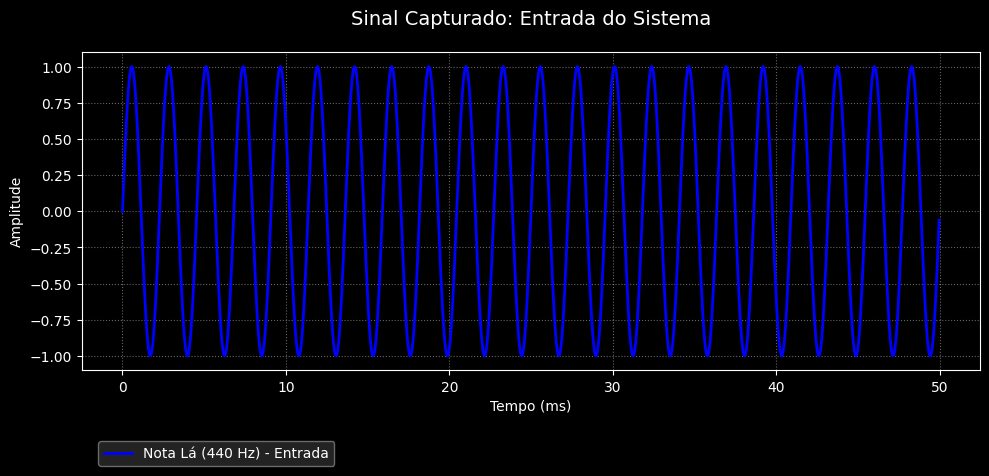

In [15]:
# Gráfico do Sinal Original
fig, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(t_ms, som_quantizado, color='blue', linewidth=2, label='Nota Lá (440 Hz) - Entrada')

ax.set_title("Sinal Capturado: Entrada do Sistema", loc='center', fontsize=14, pad=20)
ax.set_ylabel("Amplitude")
ax.set_xlabel("Tempo (ms)")
ax.grid(True, linestyle=':', alpha=0.4)

# Legenda fora do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.15, -0.2), 
          ncol=1, frameon=True, facecolor='#2d2d2d', edgecolor='gray')

plt.tight_layout()
plt.show()

O que este gráfico mostra: Este é o nosso sinal "limpo" antes de passar por qualquer sistema. Note que a amplitude varia perfeitamente entre -1 e 1. É a representação digital de uma onda sonora estável.

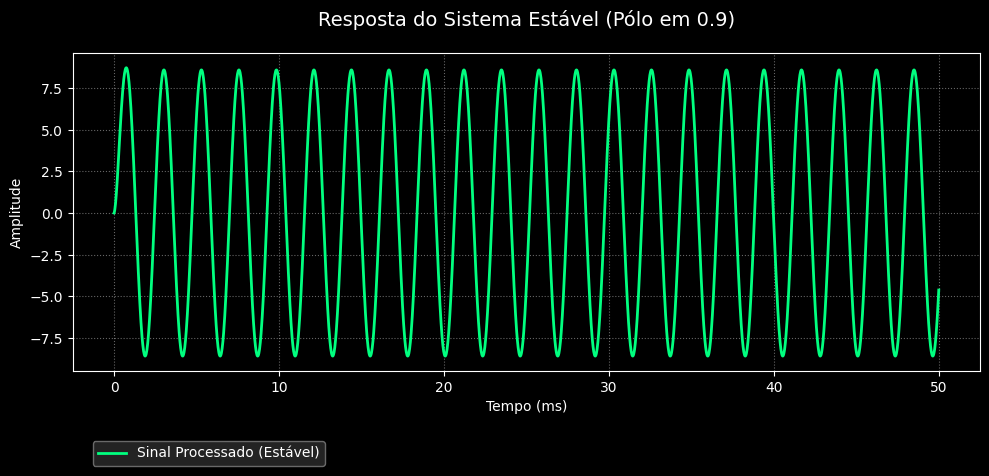

In [16]:
# Criamos a figura e o eixo no mesmo comando
fig, ax = plt.subplots(figsize=(10, 5)) 

# Plotagem dos dados
ax.plot(t_ms, saida_estavel, color='#00ff7f', linewidth=2, label='Sinal Processado (Estável)')

# Configurações de títulos e eixos (Alinhado à esquerda)
ax.set_title("Resposta do Sistema Estável (Pólo em 0.9)", loc='center', fontsize=14, pad=20)
ax.set_ylabel("Amplitude")
ax.set_xlabel("Tempo (ms)")
ax.grid(True, linestyle=':', alpha=0.4)

# O segredo da legenda: 
# bbox_to_anchor=(0.5, -0.2) joga para baixo do gráfico
# ncol=1 deixa em uma coluna
ax.legend(loc='upper center', bbox_to_anchor=(0.15, -0.2), 
          ncol=1, frameon=True, facecolor='#2d2d2d', edgecolor='gray')

# O tight_layout garante que a legenda "caiba" na imagem final
plt.tight_layout()
plt.show()

O que este gráfico mostra: Aqui vemos o sistema funcionando corretamente. Como o pólo está dentro do círculo unitário (0.9), o sistema consegue processar o sinal sem que ele saia de controle. A amplitude aumentou um pouco devido ao ganho do filtro, mas a forma da onda permanece organizada e previsível.

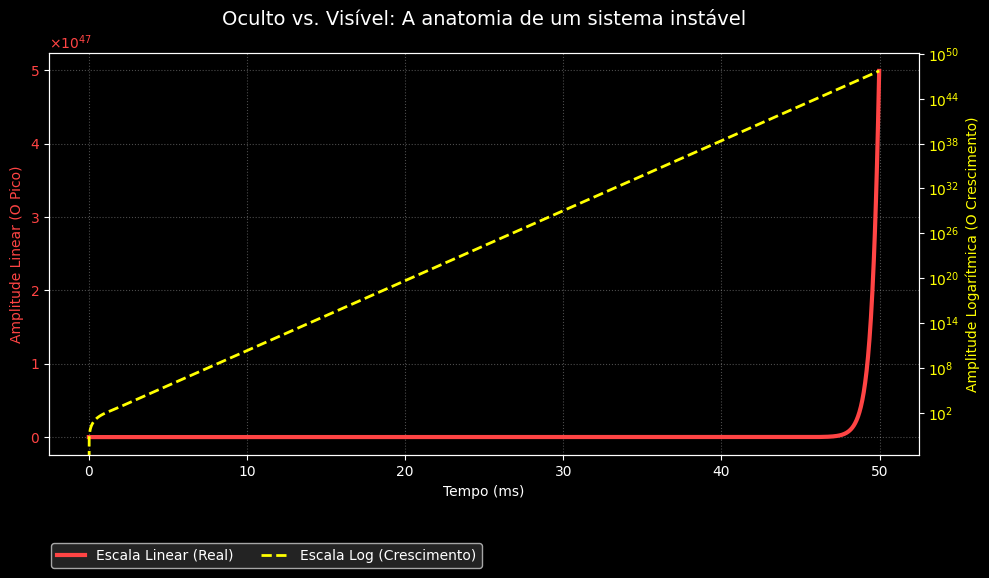

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- EIXO 1: Escala Linear (O que o olho humano vê como "pico") ---
color_linear = '#ff4444' # Vermelho
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Amplitude Linear (O Pico)', color=color_linear)
ax1.plot(t_ms, saida_instavel, color=color_linear, linewidth=3, label='Escala Linear (Real)')
# FORMATADOR DO EIXO LINEAR: Remove o 1e47 e coloca notação científica no eixo
formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1)) # Força a notação científica
ax1.yaxis.set_major_formatter(formatter)
ax1.grid(True, linestyle=':', alpha=0.3)

ax1.tick_params(axis='y', labelcolor=color_linear)

# --- EIXO 2: Escala Logarítmica (O que está acontecendo "por baixo") ---
ax2 = ax1.twinx() # Cria um segundo eixo que compartilha o mesmo eixo X
color_log = '#ffff00' # Amarelo
ax2.set_ylabel('Amplitude Logarítmica (O Crescimento)', color=color_log)
# Usamos np.abs para o logaritmo não dar erro com valores negativos
ax2.plot(t_ms, np.abs(saida_instavel), color=color_log, linestyle='--', linewidth=2, label='Escala Log (Crescimento)')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=color_log)

# Título e Legendas
plt.title("Oculto vs. Visível: A anatomia de um sistema instável", loc='center', fontsize=14, pad=20)

# Juntando as legendas dos dois eixos para ficarem embaixo
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.25, -0.2), ncol=2, frameon=True, facecolor='#2d2d2d')

plt.tight_layout()
plt.show()

O que este gráfico mostra: Este é o exemplo de um erro de projeto. Como o pólo está fora do círculo unitário (1.05), cada nova amostra de som é multiplicada por um fator maior que 1, gerando um efeito de "bola de neve". Repare na escala do eixo Y: a amplitude não está mais em 1 ou 10, ela explode para valores astronômicos rapidamente. Na prática, isso causaria um ruído ensurdecedor (microfonia) ou o travamento do software.

In [18]:
import pandas as pd
from IPython.display import display

# Selecionamos amostras do início e do fim
indices = list(range(0, 10)) + list(range(len(t) - 10, len(t)))

# Criamos a tabela formatando os números para decimais comuns
dados_tabela = {
    'Amostra (n)': [f"#{i}" for i in indices],
    'Tempo (ms)': [f"{t[i]*1000:.3f}" for i in indices],
    'Sinal Entrada (x[n])': [f"{som_quantizado[i]:.4f}" for i in indices],
    'Saída Estável': [f"{saida_estavel[i]:.4f}" for i in indices],
    # Aqui formatamos para número real com separador de milhar, sem decimais no final
    'Saída Instável (O Erro)': [f"{int(saida_instavel[i]):,}".replace(",", ".") for i in indices]
}

df_aula = pd.DataFrame(dados_tabela)
print("TABELA DIDÁTICA: O CRESCIMENTO DO ERRO")
display(df_aula)

TABELA DIDÁTICA: O CRESCIMENTO DO ERRO


,Amostra (n),Tempo (ms),Sinal Entrada (x[n]),Saída Estável,Saída Instável (O Erro)
0,#0,0.000,0.0000,0.0000,0
1,#1,0.023,0.0627,0.0627,0
2,#2,0.045,0.1251,0.1814,0
3,#3,0.068,0.1870,0.3503,0
4,#4,0.091,0.2481,0.5634,0
5,#5,0.113,0.3083,0.8154,0
6,#6,0.136,0.3673,1.1012,1
7,#7,0.159,0.4249,1.4159,1
8,#8,0.181,0.4807,1.7551,2
9,#9,0.204,0.5347,2.1143,3


### Análise dos Resultados: O Fenômeno da Instabilidade

Ao observar a tabela acima, podemos tirar três conclusões fundamentais sobre o comportamento de sistemas digitais e o tratamento de dados:

### 1. A "Calmaria" Inicial
Nas primeiras amostras (**#0 a #14**), os valores da **Saída Estável** e da **Saída Instável** são muito próximos. 
* **Lição:** Um sistema instável (mal projetado) pode parecer estar funcionando corretamente nos primeiros instantes de operação. O "erro" de 5% (polo em 1.05) ainda não acumulou o suficiente para ser notado.

### 2. O Crescimento Exponencial (Efeito "Bola de Neve")
Diferente da Saída Estável, que se mantém em valores baixos e controlados, a Saída Instável utiliza a fórmula recursiva: 
$$y[n] = x[n] + 1.05 \cdot y[n-1]$$
Como multiplicamos o resultado anterior por um fator maior que 1 (**1.05**) sucessivamente, o erro não cresce de forma linear (soma), mas sim de forma **exponencial**.

### 3. O Colapso dos Dados (A Explosão Final)
Repare nas últimas amostras. Em apenas **50 milissegundos**, o valor da Saída Instável saltou de unidades para um número com **mais de 40 dígitos**.
* **Na Prática:** Se este sistema estivesse controlando o volume de uma caixa de som, ela seria destruída. Em um banco de dados, isso causaria um erro de *Buffer Overflow* (estouro de memória), travando toda a aplicação.

> **Conclusão Acadêmica:** A estabilidade não é apenas um detalhe matemático; é um requisito de **Governança e Segurança**. Um sistema fora de conformidade com os limites de projeto (círculo unitário da Transformada Z) transforma sinais úteis em ruído catastrófico em uma fração de segundo.

# Diagramas de Polos e Zeros (Plano Z)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


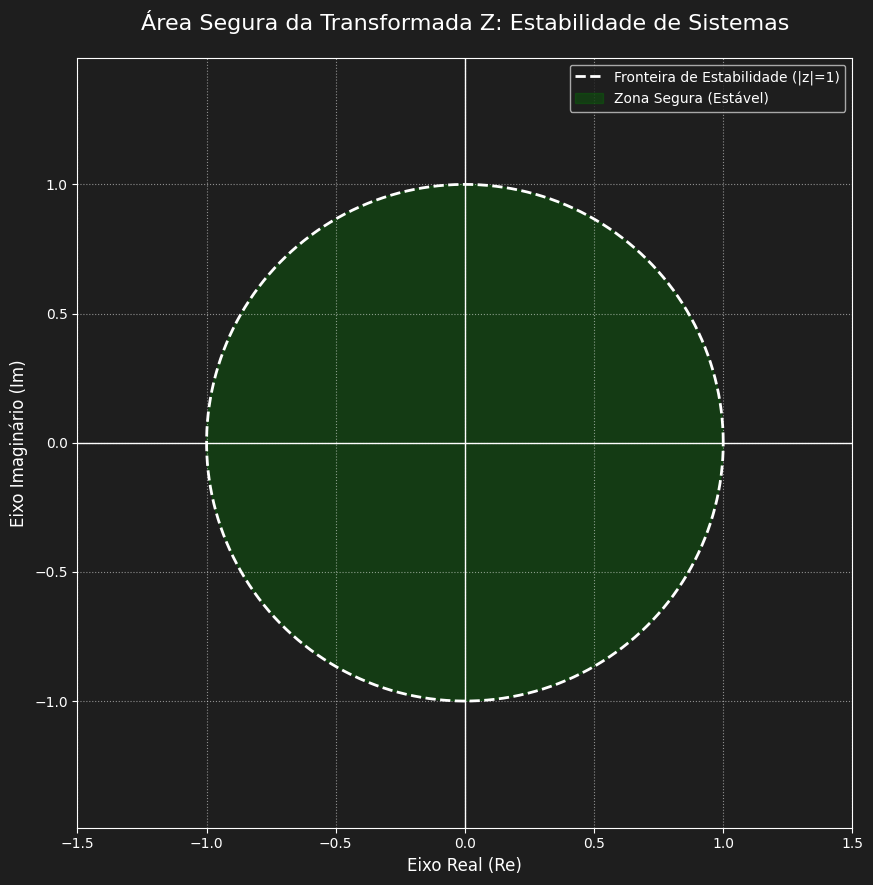

In [13]:
# ==========================================
# CONFIGURAÇÃO DO PLANO Z (ÁREA SEGURA)
# ==========================================
plt.figure(figsize=(10, 10)) # Tamanho quadrado para facilitar a proporção

# 1. Criando o Círculo Unitário (|z| = 1)
theta = np.linspace(0, 2*np.pi, 200)
x_circulo = np.cos(theta)
y_circulo = np.sin(theta)

# 2. Desenhando a linha do círculo e preenchendo a área interna
plt.plot(x_circulo, y_circulo, color='white', linestyle='--', linewidth=2, label='Fronteira de Estabilidade (|z|=1)')
plt.fill(x_circulo, y_circulo, color='green', alpha=0.3, label='Zona Segura (Estável)')

# 3. Adicionando as linhas de centro (Vertical e Horizontal)
plt.axhline(0, color='white', linewidth=1) # Linha horizontal (Eixo Real)
plt.axvline(0, color='white', linewidth=1) # Linha vertical (Eixo Imaginário)

# ==========================================
# FORMATAÇÃO VISUAL DO GRÁFICO
# ==========================================
# O comando chave para o círculo NÃO ficar oval
plt.axis('equal') 

plt.title("Área Segura da Transformada Z: Estabilidade de Sistemas", fontsize=16, pad=20)
plt.xlabel("Eixo Real (Re)", fontsize=12)
plt.ylabel("Eixo Imaginário (Im)", fontsize=12)

# Ajuste de limites para centralizar o círculo
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')

# Estilo Dark para combinar com o VS Code (Opcional)
plt.style.use('dark_background') 

plt.show()

### Análise de Estabilidade no Plano Z (Transformada Z)
Este gráfico representa a ferramenta fundamental para o diagnóstico de sistemas digitais. 
No Ciclo de Vida da Informação, após a captura pelo ADC, o sinal é processado por algoritmos que possuem um "DNA" matemático composto por Pólos e Zeros.
Componentes do Gráfico: 
1. Círculo Unitário ($|z| = 1$): É a fronteira crítica da estabilidade - Ele separa o comportamento funcional do sistema do comportamento caótico.
2. Zona Segura (Área Verde): Representa a região de estabilidade - Qualquer componente do sistema (pólo) localizado dentro desta área garante que o sinal não crescerá infinitamente, permitindo um processamento seguro e controlado.
3. Eixos Real (Re) e Imaginário (Im): Formam o plano complexo onde mapeamos a resposta em frequência do sistema.
4. Linha Vertical (Eixo Imaginário): Adicionada para fornecer simetria e auxiliar na identificação visual da posição dos pólos em relação à origem.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


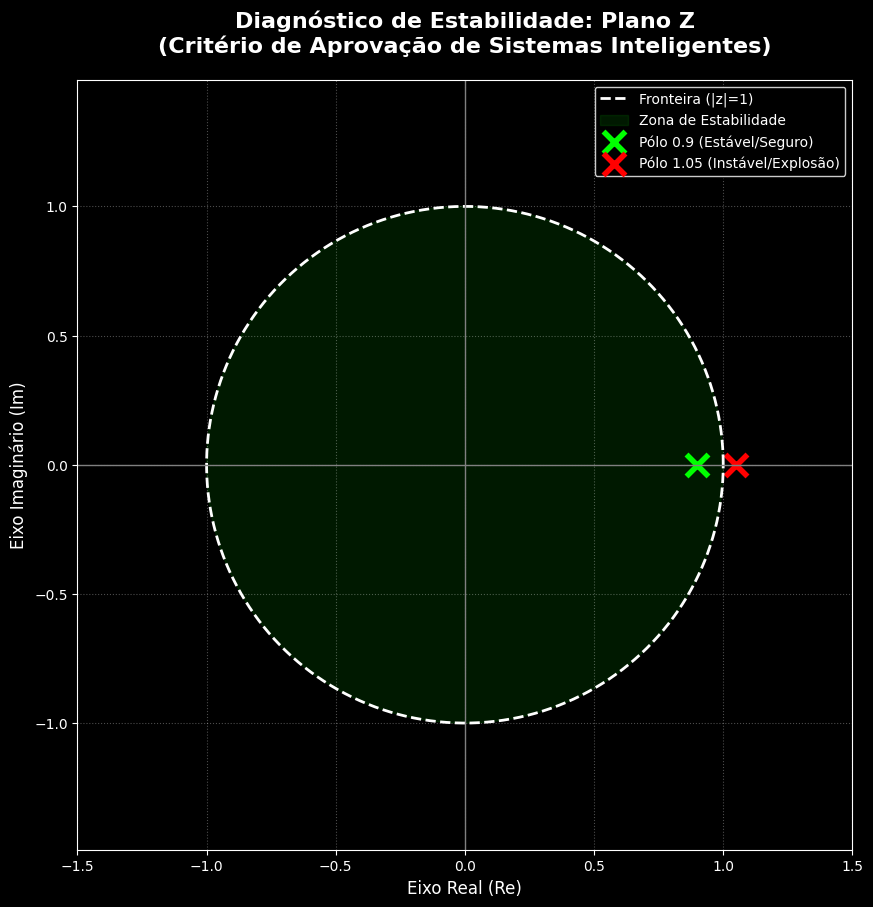

In [19]:
# Configuração do Estilo (Dark Mode para visual profissional)
plt.style.use('dark_background')
plt.figure(figsize=(10, 10))

# 1. Desenho do Círculo Unitário (Fronteira Crítica)
theta = np.linspace(0, 2*np.pi, 200)
x_circulo = np.cos(theta)
y_circulo = np.sin(theta)

plt.plot(x_circulo, y_circulo, color='white', linestyle='--', linewidth=2, label='Fronteira (|z|=1)')
plt.fill(x_circulo, y_circulo, color='green', alpha=0.2, label='Zona de Estabilidade')

# 2. Inserção dos Marcadores de Diagnóstico (Pólos)
# Pólo 0.9: Dentro do círculo (Aprovado)
plt.scatter(0.9, 0, marker='x', color='lime', s=250, linewidth=4, label='Pólo 0.9 (Estável/Seguro)')

# Pólo 1.05: Fora do círculo (Perigo)
plt.scatter(1.05, 0, marker='x', color='red', s=250, linewidth=4, label='Pólo 1.05 (Instável/Explosão)')

# 3. Elementos de Geometria e Eixos
plt.axhline(0, color='gray', linewidth=1) # Linha Horizontal
plt.axvline(0, color='gray', linewidth=1) # Linha Vertical
plt.axis('equal') # Impede que o círculo fique oval

# 4. Títulos e Legendas
plt.title("Diagnóstico de Estabilidade: Plano Z\n(Critério de Aprovação de Sistemas Inteligentes)", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Eixo Real (Re)", fontsize=12)
plt.ylabel("Eixo Imaginário (Im)", fontsize=12)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=True)

plt.show()

### O Círculo Unitário: Representa a linha de chegada da segurança. 

* Marcador Verde (0.9): Mostra um sistema que, após um estímulo, consegue retornar ao equilíbrio. É o comportamento esperado para sensores de automação e sistemas de BI.

* Marcador Vermelho (1.05): Mostra um sistema que "perde as estribeiras". No mundo real, isso significa que um erro de processamento pode fazer um motor acelerar sem parar ou um gráfico de BI gerar valores infinitos, quebrando a lógica do sistema.

A Linha Vertical: Ajuda a identificar a fase do sinal, sendo essencial para o diagnóstico completo em Processamento Digital de Sinais.

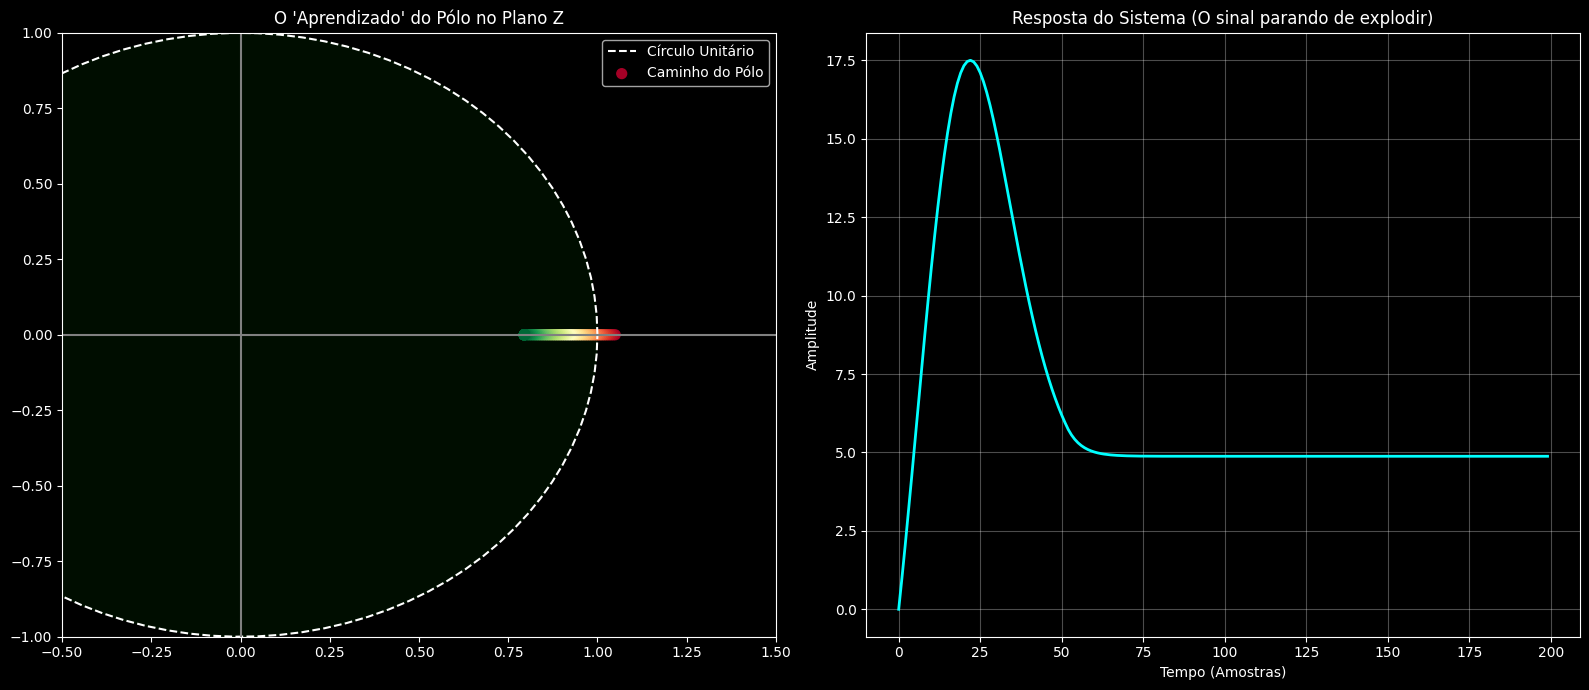

In [21]:
# 1. Configuração do Cenário
passos = 200
t = np.arange(passos)
sinal_entrada = np.ones(passos) # Um sinal constante de valor 1
saida = np.zeros(passos)
trajetoria_polos = []

# 2. Simulação do Aprendizado (O perigo do IIR)
# Começamos com um pólo perigoso (1.05) e o sistema vai "aprendendo" a baixar
polo_atual = 1.05 

for n in range(1, passos):
    # Equação do Filtro IIR: y[n] = a * y[n-1] + x[n]
    saida[n] = polo_atual * saida[n-1] + sinal_entrada[n]
    
    trajetoria_polos.append(polo_atual)
    
    # Simulação do aprendizado: o sistema percebe o erro e reduz o pólo
    if polo_atual > 0.8:
        polo_atual -= 0.005 # Reduzindo o pólo gradualmente para estabilizar

# ==========================================
# Célula 2: Visualização do Diagnóstico (Plano Z + Resposta no Tempo)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.style.use('dark_background')

# Gráfico 1: A Trajetória do Pólo no Plano Z
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.cos(theta), np.sin(theta), 'w--', label='Círculo Unitário')
ax1.fill(np.cos(theta), np.sin(theta), color='green', alpha=0.1)

# Plotando o caminho do pólo (do Vermelho para o Verde)
ax1.scatter(trajetoria_polos, np.zeros(len(trajetoria_polos)), 
            c=trajetoria_polos, cmap='RdYlGn_r', s=50, label='Caminho do Pólo')
ax1.set_title("O 'Aprendizado' do Pólo no Plano Z")
ax1.set_xlim(-0.5, 1.5)
ax1.set_ylim(-1, 1)
ax1.axvline(0, color='gray')
ax1.axhline(0, color='gray')
ax1.legend()

# Gráfico 2: O Resultado no Sinal (Resposta no Tempo)
ax2.plot(t, saida, color='cyan', linewidth=2)
ax2.set_title("Resposta do Sistema (O sinal parando de explodir)")
ax2.set_xlabel("Tempo (Amostras)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()